In [11]:
import numpy as np
from evolml.models import *
from sklearn.linear_model import *
from sklearn.datasets import load_breast_cancer, make_classification, load_digits
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

In [2]:
# X, y = load_breast_cancer(return_X_y=True)
# X, y = make_classification(1000)
X, y = load_digits(return_X_y=True)
print(X.shape)
print(y.shape)
X_train_base, X_test_base, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True)

X_scaler = MinMaxScaler()
X_train = X_scaler.fit_transform(X_train_base)
X_test = X_scaler.transform(X_test_base)
print(X_train.min(), X_train.max())
print(X_test.min(), X_test.max())

(1797, 64)
(1797,)
0.0 1.0
0.0 1.0909090909090908


In [9]:
# model = RBFNNClassifier(10, probability=False, std_from_clusters=True)
# model = RBFNNClassifier(10, probability=False, std_from_clusters=False)
# model = RBFNNClassifier(10, probability=True, std_from_clusters=True)
model = RBFNNClassifier(10, probability=True, std_from_clusters=False)
# model = LogisticRegression()
model = model.fit(X_train, y_train)
display(model)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

RBFNNClassifier(cluster_model=KMeans(n_clusters=10),
                linear_layer=LogisticRegression(penalty=None), n_units=10)

[Text(0.5, 1.0, 'Test')]

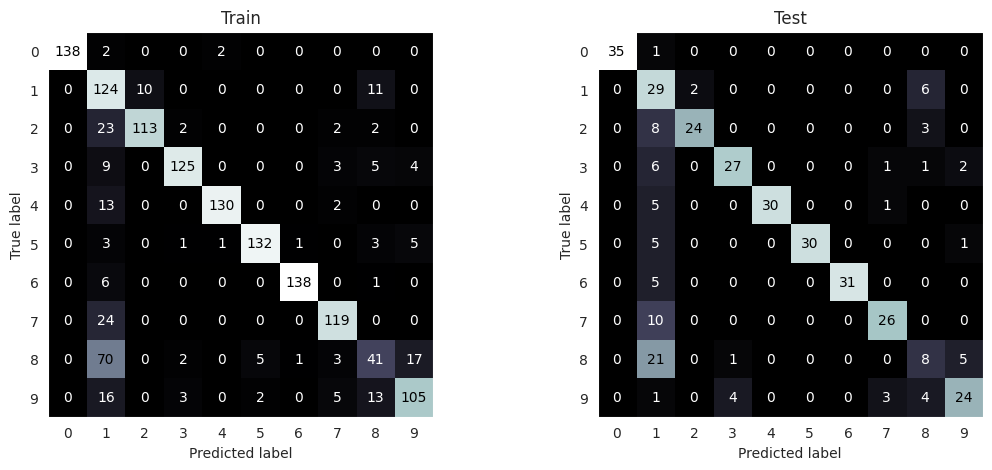

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(y_train, pred_train, ax=ax[0], colorbar=False, cmap="bone")
ax[0].set(title="Train")
ConfusionMatrixDisplay.from_predictions(y_test, pred_test, ax=ax[1], colorbar=False, cmap="bone")
ax[1].set(title="Test")